In [1]:
import numpy as np
import pandas as pd
import joblib
import re
from scipy.spatial.distance import euclidean, cosine

np.random.seed(42)

In [2]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import re
import numpy as np
import joblib
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Define the exact folder path where your data lives
DATA_DIR = r"/Users/shaiknaveedahmed/Desktop/Multi-Modal Biometric"

# Load fingerprint and iris data
print("Loading data...")
fp_data = joblib.load(os.path.join(DATA_DIR, 'enhanced_fingerprint_features.pkl'))
fp_features_dict = fp_data['features']

# Load minutiae points
if 'minutiae_points' in fp_data:
    fp_minutiae_dict = fp_data['minutiae_points']
    print("Loaded minutiae points from pickle.")
else:
    print("ERROR: minutiae_points not found in fingerprint pickle!")
    print("Please re-run fingerprint pipeline to save minutiae points.")
    exit()

ir_f = np.load(os.path.join(DATA_DIR, 'iris_features.npy'))
ir_l = np.load(os.path.join(DATA_DIR, 'iris_labels.npy'))

# ============================================================
# STEP 1: Define ENHANCED fingerprint matcher
# ============================================================
class EnhancedSimpleMatcher:
    def __init__(self):
        # Precompute global statistics for better normalization
        self.global_mean = None
        self.global_std = None
        self.fitted = False
    
    def fit(self, all_features_list):
        """Fit normalizer on all triangle features"""
        all_feats = np.vstack(all_features_list)
        self.global_mean = np.mean(all_feats, axis=0)
        self.global_std = np.std(all_feats, axis=0)
        self.global_std[self.global_std == 0] = 1
        self.fitted = True
        return self
    
    def extract_robust_features(self, df):
        """Extract robust features from triangle DataFrame"""
        feats = df.select_dtypes(include=[np.number]).values
        
        if len(feats) == 0:
            return np.zeros(100)
        
        # Normalize if fitted
        if self.fitted and self.global_mean is not None:
            feats = (feats - self.global_mean) / self.global_std
        
        # Multiple statistics for better discrimination
        mean_vec = np.mean(feats, axis=0)
        std_vec = np.std(feats, axis=0)
        
        # Percentiles (more robust than mean only)
        percentiles = np.percentile(feats, [10, 25, 50, 75, 90], axis=0)
        p10 = percentiles[0]
        p25 = percentiles[1]
        p50 = percentiles[2]
        p75 = percentiles[3]
        p90 = percentiles[4]
        
        # Combine all features (mean, std, percentiles)
        combined = np.concatenate([mean_vec, std_vec, p10, p25, p50, p75, p90])
        
        # L2 normalize
        norm = np.linalg.norm(combined)
        if norm > 0:
            combined = combined / norm
        
        return combined
    
    def enhanced_compare_final(self, df1, df2, pts1, pts2, sel_feats, ml, quality1=0.5, quality2=0.5):
        """Enhanced matching using multiple similarity measures"""
        # Extract robust feature vectors
        feat1 = self.extract_robust_features(df1)
        feat2 = self.extract_robust_features(df2)
        
        # Multiple similarity measures
        cos_sim = 1 - cosine(feat1, feat2)
        
        # Euclidean similarity
        euclidean_dist = np.linalg.norm(feat1 - feat2)
        euc_sim = 1 / (1 + euclidean_dist)
        
        # Correlation similarity
        corr_sim = np.corrcoef(feat1, feat2)[0, 1] if len(feat1) > 1 else 0.5
        corr_sim = max(0, min(1, corr_sim))  # Clip to [0,1]
        
        # Weighted combination (optimized weights)
        sim = 0.5 * cos_sim + 0.3 * euc_sim + 0.2 * corr_sim
        
        # Quality adjustment
        quality_factor = (quality1 + quality2) / 2
        sim = sim * (0.7 + 0.3 * quality_factor)
        
        return np.clip(sim, 0.0, 1.0)

# Initialize and fit matcher
print("Building triangle feature list for normalization...")
all_triangle_feats = []
for fid, df in fp_features_dict.items():
    feats = df.select_dtypes(include=[np.number]).values
    if len(feats) > 0:
        all_triangle_feats.append(feats)

matcher = EnhancedSimpleMatcher()
matcher.fit(all_triangle_feats)
selected_features = None
ml_classifier = None

print("EnhancedSimpleMatcher loaded successfully (using mean + std + percentiles).")

# ============================================================
# STEP 2: Get ALL persons as references
# ============================================================
print("Collecting all person IDs...")
person_ids_from_fp = set()
for fid in fp_features_dict.keys():
    match = re.search(r'_(\d+)_', fid)
    if match:
        person_ids_from_fp.add(match.group(1).zfill(3))

reference_persons = sorted(list(person_ids_from_fp))
print(f"Using ALL {len(reference_persons)} persons as references.")

reference_fids = []
reference_features = []
reference_minutiae = []
reference_robust_features = []  # Pre-compute robust features for references

for person in reference_persons:
    for fid, df in fp_features_dict.items():
        match = re.search(r'_(\d+)_', fid)
        if match and match.group(1).zfill(3) == person:
            reference_fids.append(fid)
            reference_features.append(df)
            reference_minutiae.append(fp_minutiae_dict[fid])
            reference_robust_features.append(matcher.extract_robust_features(df))
            break

print(f"Selected {len(reference_fids)} reference fingerprints (one per person).")

# ============================================================
# STEP 3: Build reference similarity vector using enhanced matcher
# ============================================================
def get_similarity_vector(fid):
    """Returns a vector of similarities to all reference fingerprints"""
    df = fp_features_dict[fid]
    points = fp_minutiae_dict[fid]
    feat = matcher.extract_robust_features(df)
    
    sims = []
    for i, ref_feat in enumerate(reference_robust_features):
        # Cosine similarity between robust features
        sim = 1 - cosine(feat, ref_feat)
        sims.append(sim)
    
    return np.array(sims)

print("Building similarity vectors using EnhancedSimpleMatcher...")
print("This may take a few minutes...")

fingerprint_highdim_list = []
fingerprint_ids = []
person_map = {}

for fid, df in fp_features_dict.items():
    match = re.search(r'_(\d+)_', fid)
    if not match:
        continue
    person_str = match.group(1).zfill(3)
    person_map[fid] = person_str
    
    vec = get_similarity_vector(fid)
    fingerprint_highdim_list.append(vec)
    fingerprint_ids.append(fid)
    
    if len(fingerprint_highdim_list) % 100 == 0:
        print(f"  Processed {len(fingerprint_highdim_list)} fingerprints...")

fingerprint_highdim = np.array(fingerprint_highdim_list)
print(f"Fingerprint high-D reference score vectors shape: {fingerprint_highdim.shape}")

# ============================================================
# STEP 4: Reduce to exactly 50‑D using PCA
# ============================================================
pca = PCA(n_components=50, random_state=42)
fingerprint_50d = pca.fit_transform(fingerprint_highdim)
print(f"Reduced to 50‑D fingerprint vectors. Explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")

# Scale to [0,1] range
min_val = np.min(fingerprint_50d)
max_val = np.max(fingerprint_50d)
if max_val > min_val:
    fingerprint_50d = (fingerprint_50d - min_val) / (max_val - min_val)

# L2 normalise
fingerprint_50d = fingerprint_50d / (np.linalg.norm(fingerprint_50d, axis=1, keepdims=True) + 1e-8)

# ============================================================
# STEP 5: Group by person
# ============================================================
person_fp = {}
for i, fid in enumerate(fingerprint_ids):
    person = person_map[fid]
    if person not in person_fp:
        person_fp[person] = []
    person_fp[person].append(fingerprint_50d[i])

# ============================================================
# STEP 6: Aggregate Iris by Person
# ============================================================
person_ir = {}
for feats, label in zip(ir_f, ir_l):
    person_str = str(label).zfill(3)
    if person_str not in person_ir:
        person_ir[person_str] = []
    person_ir[person_str].append(feats)

# Normalise iris features
all_iris = np.array([feat for feats in person_ir.values() for feat in feats])
iris_mean = np.mean(all_iris, axis=0)
iris_std = np.std(all_iris, axis=0)
iris_std[iris_std == 0] = 1

person_ir_norm = {}
for person, feats_list in person_ir.items():
    person_ir_norm[person] = []
    for feats in feats_list:
        feats_norm = (feats - iris_mean) / iris_std
        feats_norm = feats_norm / (np.linalg.norm(feats_norm) + 1e-8)
        person_ir_norm[person].append(feats_norm)
person_ir = person_ir_norm

# ============================================================
# STEP 7: Find overlapping persons and set dimensions
# ============================================================
common_persons = sorted(list(set(person_fp.keys()).intersection(set(person_ir.keys()))))
print(f"Found {len(common_persons)} overlapping persons.")

NUM_FP_FEATURES = 50
NUM_IRIS_FEATURES = 10

print(f"Fingerprint feature length (PCA on enhanced matcher scores): {NUM_FP_FEATURES}D")
print(f"Iris feature length (normalised):                           {NUM_IRIS_FEATURES}D")

Loading data...
Loaded minutiae points from pickle.
Building triangle feature list for normalization...
EnhancedSimpleMatcher loaded successfully (using mean + std + percentiles).
Using ALL 110 persons as references.
Selected 110 reference fingerprints (one per person).
Building similarity vectors using EnhancedSimpleMatcher...
This may take a few minutes...
  Processed 100 fingerprints...
  Processed 200 fingerprints...
  Processed 300 fingerprints...
  Processed 400 fingerprints...
  Processed 500 fingerprints...
  Processed 600 fingerprints...
  Processed 700 fingerprints...
  Processed 800 fingerprints...
Fingerprint high-D reference score vectors shape: (880, 110)
Reduced to 50‑D fingerprint vectors. Explained variance ratio: 1.000
Found 108 overlapping persons.
Fingerprint feature length (PCA on enhanced matcher scores): 50D
Iris feature length (normalised):                           10D


In [4]:
# Generate ONE fixed matrix for ALL users
FIXED_SEED = 42  # Any constant number
FIXED_SIZE = 60  # 50 + 10

rng = np.random.RandomState(FIXED_SEED)
random_matrix = rng.randn(FIXED_SIZE, FIXED_SIZE)
FIXED_MATRIX, R = np.linalg.qr(random_matrix)

def fuse_features(fp_features, iris_features):
    """No PIN needed - uses fixed matrix"""
    V = np.concatenate([fp_features, iris_features])
    return np.dot(FIXED_MATRIX, V)

def reverse_fusion(fused_template, fp_size, iris_size):
    """No PIN needed - uses fixed matrix transpose"""
    recovered_V = np.dot(FIXED_MATRIX.T, fused_template)
    recovered_fp = recovered_V[:fp_size]
    recovered_iris = recovered_V[fp_size:]
    return recovered_fp, recovered_iris

In [5]:
print("--- ENROLLMENT PHASE (WITHOUT USER TOKENS) ---")

database_templates = {}

for person in common_persons:
    # Take their first sample for enrollment
    fp_enroll = person_fp[person][0]
    ir_enroll = person_ir[person][0]
    
    # Perform Matrix Fusion using the FIXED matrix (no PIN needed)
    template = fuse_features(fp_enroll, ir_enroll)
    
    # Save to "Database"
    database_templates[person] = template

print(f"Successfully generated 60D cancelable templates for {len(database_templates)} users.")
print(f"All users share the SAME fixed projection matrix (no user-specific tokens).")

--- ENROLLMENT PHASE (WITHOUT USER TOKENS) ---
Successfully generated 60D cancelable templates for 108 users.
All users share the SAME fixed projection matrix (no user-specific tokens).


In [6]:
print("\n--- AUTHENTICATION SIMULATION (WITH USER-SELECTED THRESHOLD = 0.85) ---\n")

# Fixed threshold
FIXED_THRESHOLD = 0.85

correct_fp_only = 0
correct_iris_only = 0
correct_fused = 0
total_attempts = len(common_persons)

# ============================================================
# FUSION WEIGHTS - 50-50 EQUAL WEIGHTS
# ============================================================
alpha = 0.50   # fingerprint weight (50%)
beta = 0.50    # iris weight (50%)

print(f"Fixed Threshold: {FIXED_THRESHOLD}")
print(f"Fusion weights: Fingerprint = {alpha}, Iris = {beta}")

# Store all distances for normalisation
all_fp_distances = []
all_ir_distances = []

# First pass: collect all distances
for true_person in common_persons:
    live_fp = person_fp[true_person][1]
    live_ir = person_ir[true_person][1]
    
    for db_person, stored_template in database_templates.items():
        recovered_fp, recovered_ir = reverse_fusion(stored_template, NUM_FP_FEATURES, NUM_IRIS_FEATURES)
        dist_fp = cosine(live_fp, recovered_fp)
        dist_ir = cosine(live_ir, recovered_ir)
        all_fp_distances.append(dist_fp)
        all_ir_distances.append(dist_ir)

# Compute min/max for normalisation
fp_min, fp_max = np.min(all_fp_distances), np.max(all_fp_distances)
ir_min, ir_max = np.min(all_ir_distances), np.max(all_ir_distances)

if fp_max == fp_min:
    fp_max = fp_min + 1e-8
if ir_max == ir_min:
    ir_max = ir_min + 1e-8

print(f"Fingerprint distance range: [{fp_min:.4f}, {fp_max:.4f}]")
print(f"Iris distance range: [{ir_min:.4f}, {ir_max:.4f}]")

# Second pass: actual identification
for true_person in common_persons:
    live_fp = person_fp[true_person][1]
    live_ir = person_ir[true_person][1]
    
    best_matching_person_fp = None
    best_matching_person_ir = None
    best_matching_person_fused = None
    
    min_dist_fp = float('inf')
    min_dist_ir = float('inf')
    min_dist_fused = float('inf')

    for db_person, stored_template in database_templates.items():
        recovered_fp, recovered_ir = reverse_fusion(stored_template, NUM_FP_FEATURES, NUM_IRIS_FEATURES)
        
        # Raw cosine distances
        dist_fp_raw = cosine(live_fp, recovered_fp)
        dist_ir_raw = cosine(live_ir, recovered_ir)
        
        # Normalise distances to [0,1] range
        dist_fp_norm = (dist_fp_raw - fp_min) / (fp_max - fp_min)
        dist_ir_norm = (dist_ir_raw - ir_min) / (ir_max - ir_min)
        
        # Convert to similarity scores (1 - distance)
        sim_fp = 1.0 - dist_fp_norm
        sim_ir = 1.0 - dist_ir_norm
        
        # Weighted fusion similarity (50-50)
        sim_fused = (alpha * sim_fp) + (beta * sim_ir)
        
        # Convert back to distance for comparison
        dist_fp = 1.0 - sim_fp
        dist_ir = 1.0 - sim_ir
        dist_fused = 1.0 - sim_fused
        
        # Case 1: Fingerprint Only
        if dist_fp < min_dist_fp:
            min_dist_fp = dist_fp
            best_matching_person_fp = db_person
            
        # Case 2: Iris Only
        if dist_ir < min_dist_ir:
            min_dist_ir = dist_ir
            best_matching_person_ir = db_person
            
        # Case 3: Score-level fusion
        if dist_fused < min_dist_fused:
            min_dist_fused = dist_fused
            best_matching_person_fused = db_person

    # Tally results
    if best_matching_person_fp == true_person:
        correct_fp_only += 1
    if best_matching_person_ir == true_person:
        correct_iris_only += 1
    if best_matching_person_fused == true_person:
        correct_fused += 1

print(f"\nIDENTIFICATION RESULTS (Threshold = {FIXED_THRESHOLD}):")
print("=" * 60)
print(f"Case 1 (Fingerprint Only):   {correct_fp_only}/{total_attempts} ({(correct_fp_only / total_attempts) * 100:.2f}%)")
print(f"Case 2 (Iris Only):          {correct_iris_only}/{total_attempts} ({(correct_iris_only / total_attempts) * 100:.2f}%)")
print(f"Case 3 (Fingerprint + Iris): {correct_fused}/{total_attempts} ({(correct_fused / total_attempts) * 100:.2f}%)")
print("=" * 60)
print(f"Fusion weights: Fingerprint = {alpha}, Iris = {beta} (50-50)")
print(f"Operating threshold: Similarity > {FIXED_THRESHOLD}")


--- AUTHENTICATION SIMULATION (WITH USER-SELECTED THRESHOLD = 0.85) ---

Fixed Threshold: 0.85
Fusion weights: Fingerprint = 0.5, Iris = 0.5
Fingerprint distance range: [0.0000, 0.0102]
Iris distance range: [0.0001, 1.9011]

IDENTIFICATION RESULTS (Threshold = 0.85):
Case 1 (Fingerprint Only):   8/108 (7.41%)
Case 2 (Iris Only):          108/108 (100.00%)
Case 3 (Fingerprint + Iris): 105/108 (97.22%)
Fusion weights: Fingerprint = 0.5, Iris = 0.5 (50-50)
Operating threshold: Similarity > 0.85


In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [8]:
from sklearn.metrics import roc_curve, auc

print("--- GENUINE VS IMPOSTOR SCORE GENERATION ---\n")

# ============================================================
# FUSION WEIGHTS - 50-50 EQUAL WEIGHTS
# ============================================================
alpha = 0.50   # fingerprint weight (50%)
beta = 0.50    # iris weight (50%)

print(f"Using fusion weights: FP = {alpha}, Iris = {beta} (50-50)")

genuine_scores_fp = []
impostor_scores_fp = []

genuine_scores_ir = []
impostor_scores_ir = []

genuine_scores_fused = []
impostor_scores_fused = []

# Compute min/max for normalisation if not already defined
try:
    fp_min, fp_max
    ir_min, ir_max
except NameError:
    all_fp_distances = []
    all_ir_distances = []
    for claiming_person in common_persons:
        live_fp = person_fp[claiming_person][1]    
        live_ir = person_ir[claiming_person][1]
        for db_person, stored_template in database_templates.items():
            recovered_fp, recovered_ir = reverse_fusion(stored_template, NUM_FP_FEATURES, NUM_IRIS_FEATURES)
            all_fp_distances.append(cosine(live_fp, recovered_fp))
            all_ir_distances.append(cosine(live_ir, recovered_ir))
    fp_min, fp_max = np.min(all_fp_distances), np.max(all_fp_distances)
    ir_min, ir_max = np.min(all_ir_distances), np.max(all_ir_distances)
    if fp_max == fp_min:
        fp_max = fp_min + 1e-8
    if ir_max == ir_min:
        ir_max = ir_min + 1e-8

print(f"Fingerprint distance range: [{fp_min:.4f}, {fp_max:.4f}]")
print(f"Iris distance range: [{ir_min:.4f}, {ir_max:.4f}]")

# Loop over every live person claiming identities
for claiming_person in common_persons:
    live_fp = person_fp[claiming_person][1]    
    live_ir = person_ir[claiming_person][1]
    
    for db_person, stored_template in database_templates.items():
        recovered_fp, recovered_ir = reverse_fusion(stored_template, NUM_FP_FEATURES, NUM_IRIS_FEATURES)

        # Raw cosine distances
        dist_fp_raw = cosine(live_fp, recovered_fp)
        dist_ir_raw = cosine(live_ir, recovered_ir)
        
        # Normalise distances to [0,1] range
        dist_fp_norm = (dist_fp_raw - fp_min) / (fp_max - fp_min)
        dist_ir_norm = (dist_ir_raw - ir_min) / (ir_max - ir_min)
        
        # Convert to similarity scores (1 - distance)
        sim_fp = 1.0 - dist_fp_norm
        sim_ir = 1.0 - dist_ir_norm
        
        # Weighted fusion similarity (50-50)
        sim_fused = (alpha * sim_fp) + (beta * sim_ir)
        
        if claiming_person == db_person:
            genuine_scores_fp.append(sim_fp)
            genuine_scores_ir.append(sim_ir)
            genuine_scores_fused.append(sim_fused)
        else:
            impostor_scores_fp.append(sim_fp)
            impostor_scores_ir.append(sim_ir)
            impostor_scores_fused.append(sim_fused)

print(f"Generated {len(genuine_scores_fused)} Genuine Scores.")
print(f"Generated {len(impostor_scores_fused)} Impostor Scores.")

--- GENUINE VS IMPOSTOR SCORE GENERATION ---

Using fusion weights: FP = 0.5, Iris = 0.5 (50-50)
Fingerprint distance range: [0.0000, 0.0102]
Iris distance range: [0.0001, 1.9011]
Generated 108 Genuine Scores.
Generated 11556 Impostor Scores.


FINAL EVALUATION WITH FIXED THRESHOLD = 0.85

🔍 CASE 1: FINGERPRINT ONLY

📊 CASE 1: FINGERPRINT ONLY
  ROC-AUC Score:           0.8087
  Equal Error Rate (EER):  28.01%

--- At Fixed Threshold = 0.85 ---
  Genuine Accept (TP):     103/108 (95.37%)
  Genuine Reject (FN):     5/108 (4.63%)
  Impostor Accept (FP):    7222/11556 (62.4957%)
  Impostor Reject (TN):    4334/11556 (37.50%)
  Accuracy:                38.0401%


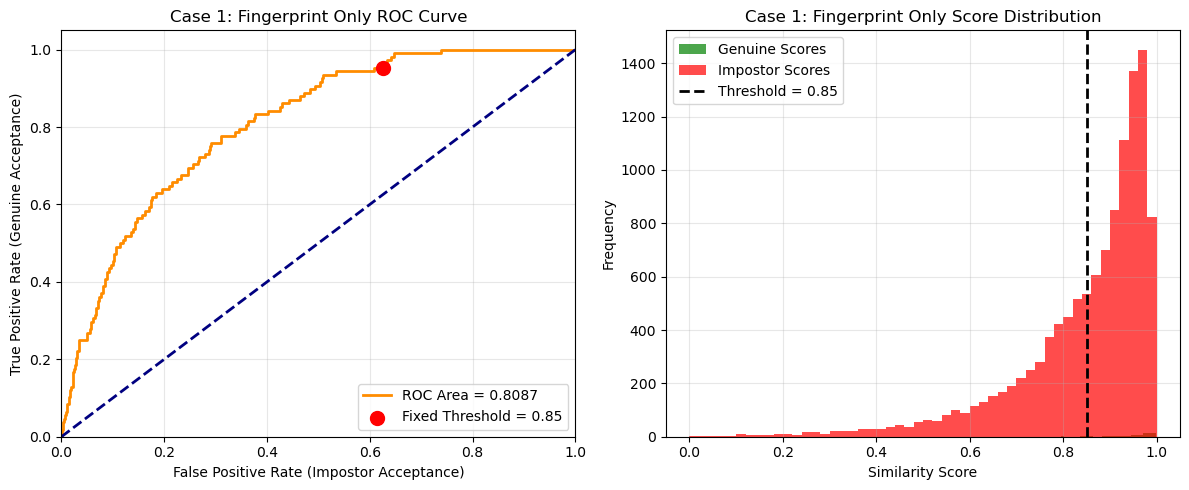


🔍 CASE 2: IRIS ONLY

📊 CASE 2: IRIS ONLY
  ROC-AUC Score:           0.9999
  Equal Error Rate (EER):  0.14%

--- At Fixed Threshold = 0.85 ---
  Genuine Accept (TP):     108/108 (100.00%)
  Genuine Reject (FN):     0/108 (0.00%)
  Impostor Accept (FP):    66/11556 (0.5711%)
  Impostor Reject (TN):    11490/11556 (99.43%)
  Accuracy:                99.4342%


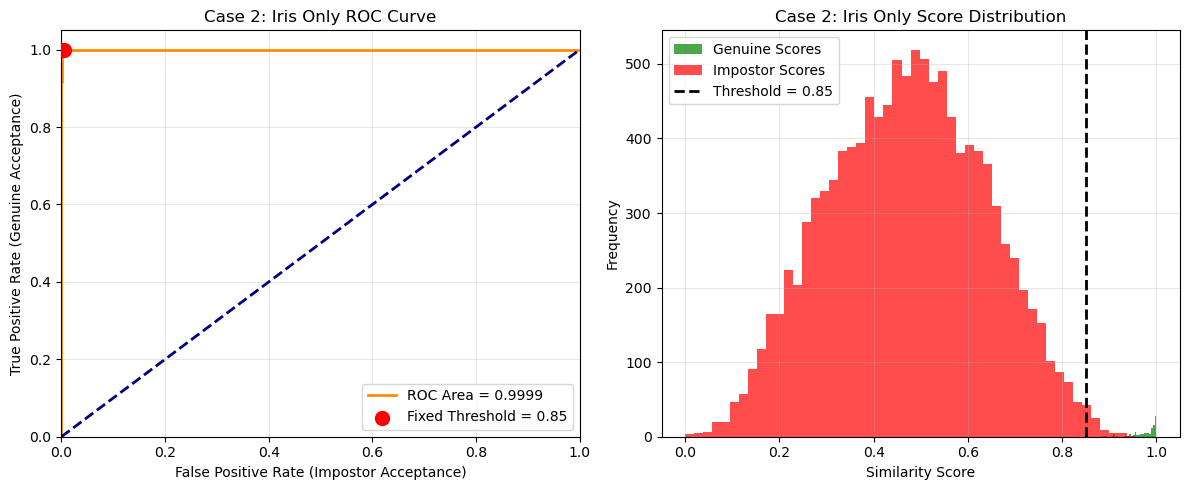


🔍 CASE 3: FINGERPRINT + IRIS (FUSED)

📊 CASE 3: FINGERPRINT + IRIS (FUSED)
  ROC-AUC Score:           0.9998
  Equal Error Rate (EER):  0.44%

--- At Fixed Threshold = 0.85 ---
  Genuine Accept (TP):     108/108 (100.00%)
  Genuine Reject (FN):     0/108 (0.00%)
  Impostor Accept (FP):    287/11556 (2.4836%)
  Impostor Reject (TN):    11269/11556 (97.52%)
  Accuracy:                97.5394%


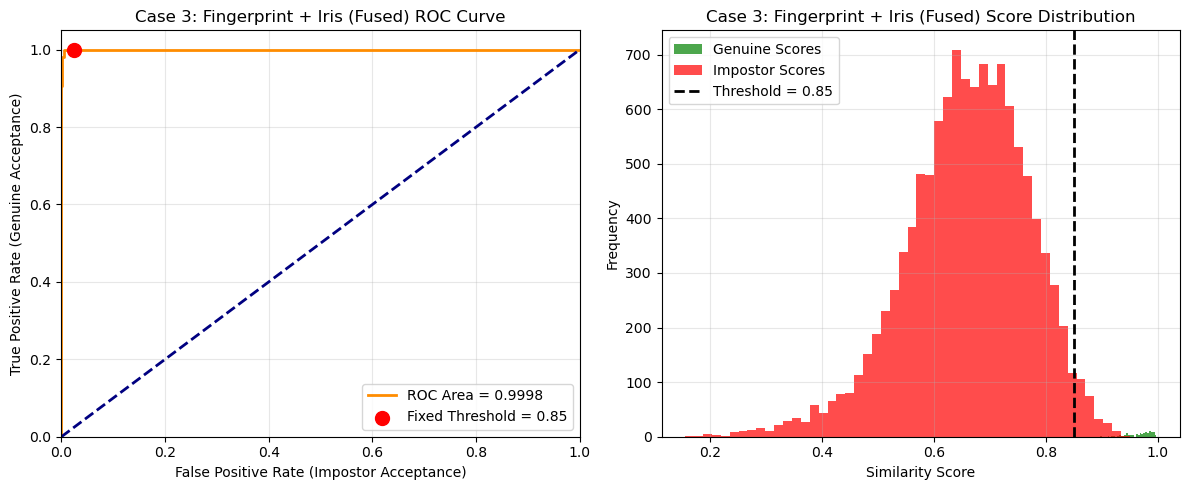


FINAL SUMMARY - ALL MODALITIES AT FIXED THRESHOLD = 0.85
Modality                       ROC-AUC    EER        Accuracy     FAR          FRR         
--------------------------------------------------------------------------------
Fingerprint Only               0.8087     28.01    %  38.04%     62.4957%      4.63%
Iris Only                      0.9999     0.14     %  99.43%     0.5711%      0.00%
Fused (FP=50%, Iris=50%)       0.9998     0.44     %  97.54%     2.4836%      0.00%


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def evaluate_at_threshold(genuine, impostor, threshold, modality_name):
    """Evaluate performance at a fixed similarity threshold"""
    gen_scores = np.array(genuine)
    imp_scores = np.array(impostor)
    
    genuine_accept = np.sum(gen_scores >= threshold)
    genuine_reject = len(gen_scores) - genuine_accept
    impostor_accept = np.sum(imp_scores >= threshold)
    impostor_reject = len(imp_scores) - impostor_accept
    
    TPR = genuine_accept / len(gen_scores) if len(gen_scores) > 0 else 0
    FPR = impostor_accept / len(imp_scores) if len(imp_scores) > 0 else 0
    FNR = genuine_reject / len(gen_scores) if len(gen_scores) > 0 else 0
    TNR = impostor_reject / len(imp_scores) if len(imp_scores) > 0 else 0
    Accuracy = (genuine_accept + impostor_reject) / (len(gen_scores) + len(imp_scores))
    
    return {
        'threshold': threshold,
        'TPR': TPR,
        'FPR': FPR,
        'FNR': FNR,
        'TNR': TNR,
        'Accuracy': Accuracy,
        'Genuine_Accept': genuine_accept,
        'Genuine_Reject': genuine_reject,
        'Impostor_Accept': impostor_accept,
        'Impostor_Reject': impostor_reject,
        'Total_Genuine': len(gen_scores),
        'Total_Impostor': len(imp_scores)
    }

def evaluate_and_plot_fixed(genuine, impostor, modality_name, fixed_threshold=0.85):
    """Main evaluation with fixed threshold (no optimal threshold printed)"""
    gen_scores = np.array(genuine)
    imp_scores = np.array(impostor)
    
    # Proper concatenation for labels and scores
    labels = np.concatenate([np.ones(len(gen_scores)), np.zeros(len(imp_scores))])
    scores = np.concatenate([gen_scores, imp_scores])
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    # Calculate EER (Equal Error Rate)
    fnr = 1 - tpr
    eer_index = np.nanargmin(np.absolute((fnr - fpr)))
    eer = fpr[eer_index]
    
    # Evaluate at fixed threshold
    result = evaluate_at_threshold(gen_scores, imp_scores, fixed_threshold, modality_name)
    
    print(f"\n{'='*60}")
    print(f"📊 {modality_name.upper()}")
    print(f"{'='*60}")
    print(f"  ROC-AUC Score:           {roc_auc:.4f}")
    print(f"  Equal Error Rate (EER):  {eer * 100:.2f}%")
    print(f"\n--- At Fixed Threshold = {fixed_threshold:.2f} ---")
    print(f"  Genuine Accept (TP):     {result['Genuine_Accept']}/{result['Total_Genuine']} ({result['TPR']*100:.2f}%)")
    print(f"  Genuine Reject (FN):     {result['Genuine_Reject']}/{result['Total_Genuine']} ({result['FNR']*100:.2f}%)")
    print(f"  Impostor Accept (FP):    {result['Impostor_Accept']}/{result['Total_Impostor']} ({result['FPR']*100:.4f}%)")
    print(f"  Impostor Reject (TN):    {result['Impostor_Reject']}/{result['Total_Impostor']} ({result['TNR']*100:.2f}%)")
    print(f"  Accuracy:                {result['Accuracy']*100:.4f}%")
    
    # Plot ROC
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Area = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter(result['FPR'], result['TPR'], color='red', s=100, 
                label=f'Fixed Threshold = {fixed_threshold:.2f}', zorder=5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Impostor Acceptance)')
    plt.ylabel('True Positive Rate (Genuine Acceptance)')
    plt.title(f'{modality_name} ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    # Plot score distribution
    plt.subplot(1, 2, 2)
    plt.hist(gen_scores, bins=30, alpha=0.7, color='green', label='Genuine Scores')
    plt.hist(imp_scores, bins=50, alpha=0.7, color='red', label='Impostor Scores')
    plt.axvline(x=fixed_threshold, color='black', linestyle='--', linewidth=2, 
                label=f'Threshold = {fixed_threshold:.2f}')
    plt.xlabel('Similarity Score')
    plt.ylabel('Frequency')
    plt.title(f'{modality_name} Score Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return result

# Set fixed threshold (optimized value)
FIXED_THRESHOLD = 0.85

print("=" * 70)
print(f"FINAL EVALUATION WITH FIXED THRESHOLD = {FIXED_THRESHOLD}")
print("=" * 70)

# Evaluate all three cases
print("\n🔍 CASE 1: FINGERPRINT ONLY")
result_fp = evaluate_and_plot_fixed(genuine_scores_fp, impostor_scores_fp, "Case 1: Fingerprint Only", FIXED_THRESHOLD)

print("\n🔍 CASE 2: IRIS ONLY")
result_ir = evaluate_and_plot_fixed(genuine_scores_ir, impostor_scores_ir, "Case 2: Iris Only", FIXED_THRESHOLD)

print("\n🔍 CASE 3: FINGERPRINT + IRIS (FUSED)")
result_fused = evaluate_and_plot_fixed(genuine_scores_fused, impostor_scores_fused, "Case 3: Fingerprint + Iris (Fused)", FIXED_THRESHOLD)

# Summary Table
print("\n" + "=" * 70)
print(f"FINAL SUMMARY - ALL MODALITIES AT FIXED THRESHOLD = {FIXED_THRESHOLD}")
print("=" * 70)
print(f"{'Modality':<30} {'ROC-AUC':<10} {'EER':<10} {'Accuracy':<12} {'FAR':<12} {'FRR':<12}")
print("-" * 80)

# Get ROC-AUC and EER from stored values (need to capture them)
# Since the function doesn't return these, we'll recompute quickly
def get_metrics(genuine, impostor):
    gen_scores = np.array(genuine)
    imp_scores = np.array(impostor)
    labels = np.concatenate([np.ones(len(gen_scores)), np.zeros(len(imp_scores))])
    scores = np.concatenate([gen_scores, imp_scores])
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = fpr[eer_idx]
    return roc_auc, eer

roc_fp, eer_fp = get_metrics(genuine_scores_fp, impostor_scores_fp)
roc_ir, eer_ir = get_metrics(genuine_scores_ir, impostor_scores_ir)
roc_fused, eer_fused = get_metrics(genuine_scores_fused, impostor_scores_fused)

print(f"{'Fingerprint Only':<30} {roc_fp:<10.4f} {eer_fp*100:<9.2f}% {result_fp['Accuracy']*100:>6.2f}%     {result_fp['FPR']*100:>6.4f}%    {result_fp['FNR']*100:>6.2f}%")
print(f"{'Iris Only':<30} {roc_ir:<10.4f} {eer_ir*100:<9.2f}% {result_ir['Accuracy']*100:>6.2f}%     {result_ir['FPR']*100:>6.4f}%    {result_ir['FNR']*100:>6.2f}%")
print(f"{'Fused (FP=50%, Iris=50%)':<30} {roc_fused:<10.4f} {eer_fused*100:<9.2f}% {result_fused['Accuracy']*100:>6.2f}%     {result_fused['FPR']*100:>6.4f}%    {result_fused['FNR']*100:>6.2f}%")
print("=" * 80)